# Ex. Seismic Refraction Tomography (SRT) Inversion and Interface Delineation

This notebook demonstrates the SRT inv workflow in PyHydroGeophysX.


In [1]:
"""
Ex. Seismic Refraction Tomography (SRT) Inversion and Interface Delineation
=======================================================================

This example demonstrates how to perform a 2D seismic refraction tomography (SRT) 
inversion and interpret the results to define subsurface structures.

The script focuses on the inversion and post-processing stages of a geophysical workflow. 
It begins by loading pre-existing synthetic travel time data and then uses tomographic inversion 
to reconstruct the subsurface P-wave velocity distribution. A key feature demonstrated is the extraction of geological interfaces based on velocity thresholds.

The workflow includes:
Loading Synthetic Data: The script loads pre-generated synthetic travel time data for both a long and a short survey profile.
Tomographic Inversion: It runs both the original PyGIMLi `TravelTimeManager.invert()` workflow and the package-level `SRTInversion` class using matching settings.
Comparison: The velocity models from both inversion paths are compared quantitatively and visually.
Visualization: The resulting velocity tomograms are plotted, showing the recovered subsurface structure.
Interface Extraction: For the long profile, the script uses the extract_velocity_interface function to automatically delineate boundaries between different geological layers (e.g., regolith, fractured bedrock, and fresh bedrock) based on velocity thresholds.
Exporting Results: The coordinates of the extracted interfaces are saved to text files, making them available for constraining other models, such as hydrogeological simulations.

"""
# sphinx_gallery_thumbnail_path = 'auto_examples/images/Ex_SRT_inv_fig_01.png'





'\nEx. Seismic Refraction Tomography (SRT) Inversion and Interface Delineation\n=======================================================================\n\nThis example demonstrates how to perform a 2D seismic refraction tomography (SRT) \ninversion and interpret the results to define subsurface structures.\n\nThe script focuses on the inversion and post-processing stages of a geophysical workflow. \nIt begins by loading pre-existing synthetic travel time data and then uses tomographic inversion \nto reconstruct the subsurface P-wave velocity distribution. A key feature demonstrated is the extraction of geological interfaces based on velocity thresholds.\n\nThe workflow includes:\nLoading Synthetic Data: The script loads pre-generated synthetic travel time data for both a long and a short survey profile.\nTomographic Inversion: It runs both the original PyGIMLi `TravelTimeManager.invert()` workflow and the package-level `SRTInversion` class using matching settings.\nComparison: The velo

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
from pygimli.physics import TravelTimeManager
import pygimli.physics.traveltime as tt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pygimli.meshtools as mt

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.model_output.modflow_output import MODFLOWWaterContent
from PyHydroGeophysX.core.interpolation import ProfileInterpolator, create_surface_lines
from PyHydroGeophysX.core.mesh_utils import MeshCreator,fill_holes_2d,createTriangles,extract_velocity_interface
from PyHydroGeophysX.petrophysics.velocity_models import HertzMindlinModel, DEMModel
from PyHydroGeophysX.inversion.srt_inversion import SRTInversion



[PyHydroGeophysX] RESIPY import failed: No module named 'resipy', using embedded parsers (modified from ResIPy)
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.25.0)


ModuleNotFoundError: No module named 'joblib'

In [ ]:
output_dir = "results/seismic_example"
os.makedirs(output_dir, exist_ok=True)


SRT_BASE_PARAMS = {
    # Parameters shared with ERT-style inversion interfaces
    "lambda_val": 50.0,
    "method": "cgls",
    "max_iterations": 20,
    "lambda_rate": 1.0,
    "lambda_min": 1.0,
    "relativeError": 0.03,
    "absoluteUError": 0.001,
    # SRT-specific controls
    "zWeight": 0.2,
    "vTop": 500.0,
    "target_chi_squared": 1.0,
}

LONG_SRT_PARAMS = {
    **SRT_BASE_PARAMS,
    "vBottom": 8000.0,
    "model_constraints": (300.0, 10000.0),
}

SHORT_SRT_PARAMS = {
    **SRT_BASE_PARAMS,
    "vBottom": 5500.0,
    "model_constraints": (300.0, 8000.0),
}


def run_custom_srt_inversion(data_file, mesh, inversion_params):
    """Run package-level SRTInversion with explicit parameter dictionary."""
    inversion = SRTInversion(
        data_file=data_file,
        mesh=mesh,
        **inversion_params,
    )
    return inversion.run()


def compare_models(direct_model, custom_result):
    custom_model = np.asarray(custom_result.final_model, dtype=float)
    if direct_model.shape != custom_model.shape:
        raise ValueError(
            f"direct/custom model size mismatch: "
            f"{direct_model.shape} vs {custom_model.shape}."
        )
    return custom_model


def plot_direct_vs_custom(
    mesh,
    direct_model,
    custom_model,
    direct_coverage,
    custom_coverage,
    sensors,
    output_name,
    velocity_limits,
    title_prefix,
):
    velocity_cmap = fixed_cmap if "fixed_cmap" in globals() else "viridis"

    fig = plt.figure(figsize=[12.5, 5.5])
    ax_direct = fig.add_subplot(1, 2, 1)
    pg.show(
        mesh,
        direct_model,
        cMap=velocity_cmap,
        coverage=direct_coverage,
        ax=ax_direct,
        cMin=velocity_limits[0],
        cMax=velocity_limits[1],
        label="Velocity (m s$^{-1}$)",
        orientation="vertical",
    )
    ax_direct.set_title(f"{title_prefix}\nPyGIMLi direct inversion", fontsize=12)
    ax_direct.set_xlabel("Distance (m)", fontsize=11)
    ax_direct.set_ylabel("Elevation (m)", fontsize=11)
    pg.viewer.mpl.drawSensors(ax_direct, sensors, diam=0.7, facecolor="black", edgecolor="black")

    ax_custom = fig.add_subplot(1, 2, 2)
    pg.show(
        mesh,
        custom_model,
        cMap=velocity_cmap,
        coverage=custom_coverage,
        ax=ax_custom,
        cMin=velocity_limits[0],
        cMax=velocity_limits[1],
        label="Velocity (m s$^{-1}$)",
        orientation="vertical",
    )
    ax_custom.set_title(f"{title_prefix}\nPyHydroGeophysX SRTInversion", fontsize=12)
    ax_custom.set_xlabel("Distance (m)", fontsize=11)
    ax_custom.set_ylabel("Elevation (m)", fontsize=11)
    pg.viewer.mpl.drawSensors(ax_custom, sensors, diam=0.7, facecolor="black", edgecolor="black")

    fig.savefig(os.path.join(output_dir, output_name), dpi=300, bbox_inches="tight")



## Long seismic profile



### Load seismic data and inversion



In [ ]:
long_data_file = "./results/SRT_forward/synthetic_seismic_data_long.dat"
datasrt = tt.load(long_data_file)
TT = pg.physics.traveltime.TravelTimeManager()
mesh_inv = TT.createMesh(datasrt, paraMaxCellSize=2, quality=32, paraDepth = 60.0)
TT.invert(datasrt, mesh = mesh_inv,lam=50,
          zWeight=0.2,vTop=500, vBottom=8000,
          verbose=1, limits=[300., 10000.])
velocity_data_long_direct = TT.model.array()
coverage_long_direct = TT.standardizedCoverage()

long_custom_result = run_custom_srt_inversion(
    data_file=long_data_file,
    mesh=mesh_inv,
    inversion_params=LONG_SRT_PARAMS,
)
velocity_data_long_custom = compare_models(
    velocity_data_long_direct,
    long_custom_result,
)
coverage_long_custom = long_custom_result.coverage



28/03/26 - 21:03:49 - pyGIMLi - INFO - Found 1 regions.


28/03/26 - 21:03:49 - pyGIMLi - INFO - Found 1 regions.


28/03/26 - 21:03:49 - pyGIMLi - INFO - Creating forward mesh from region infos.


28/03/26 - 21:03:49 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


28/03/26 - 21:03:50 - pyGIMLi - INFO - Create gradient starting model. 500: 8000


...

accepted_step: 1.000000
update_norm: 4.659947e+00
-------------------Iteration: 3 ---------------------------


chi2 (pre-update): 1.012657
dPhi (pre-update): 0.305432
phi_d (pre-update): 2703.793177
phi_m (pre-update): 25.574848
obj (pre-update): 3982.535568
lambda: 50.000000


accepted_step: 1.000000
update_norm: 2.504770e+00
-------------------Iteration: 4 ---------------------------


chi2 (pre-update): 0.974306
dPhi (pre-update): 0.037871
phi_d (pre-update): 2601.397993
phi_m (pre-update): 24.853661
obj (pre-update): 3844.081020
lambda: 50.000000
Converged: stopping criterion reached.


End of inversion


### Get parameters for plotting layers



In [ ]:
# Get coverage and cell positions
cov = TT.standardizedCoverage()
pos = np.array(mesh_inv.cellCenters())
# For layered model visualization
x, y, triangles, _, dataIndex = createTriangles(mesh_inv)
z = pg.meshtools.cellDataToNodeData(mesh_inv, velocity_data_long_direct)




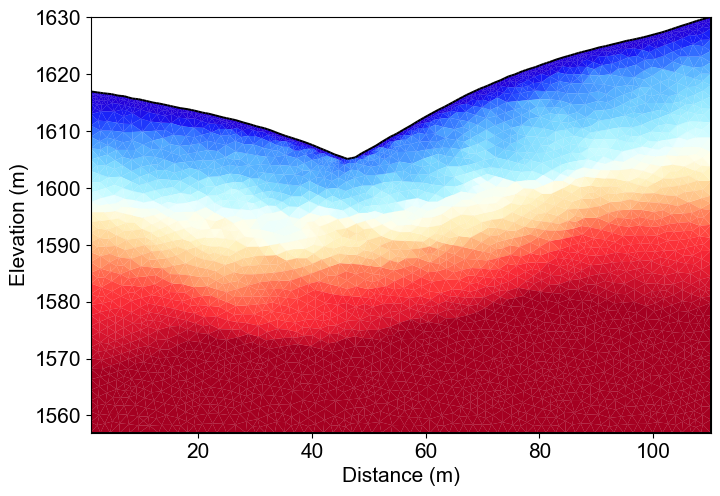

C:\Users\hchen117\.conda\envs\pg\lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 800x900 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

In [ ]:
params = {'legend.fontsize': 15,
          #'figure.figsize': (15, 5),
         'axes.labelsize': 15,
         'axes.titlesize':16,
         'xtick.labelsize':15,
         'ytick.labelsize':15}
import matplotlib.pylab as pylab
pylab.rcParams.update(params)

plt.rcParams["font.family"] = "Arial"

from palettable.lightbartlein.diverging import BlueDarkRed18_18
fixed_cmap = BlueDarkRed18_18.mpl_colormap

fig = plt.figure(figsize=[8,9])
ax1 = fig.add_subplot(1,1,1)
pg.show(mesh_inv, velocity_data_long_direct,cMap=fixed_cmap,coverage = cov,ax = ax1,label='Velocity (m s$^{-1}$)',
        xlabel="Distance (m)", ylabel="Elevation (m)",pad=0.3,cMin =500, cMax=5000
       ,orientation="vertical")
ax1.set_xlabel("Distance (m)", fontsize=15)
ax1.set_ylabel("Elevation (m)", fontsize=15)
ax1.tricontour(x, y, triangles, z, levels=[1200], linewidths=1.0, colors='k', linestyles='dashed')
ax1.tricontour(x, y, triangles, z, levels=[5000], linewidths=1.0, colors='k', linestyles='-')


pg.viewer.mpl.drawSensors(ax1, datasrt.sensors(), diam=0.9,
                         facecolor='black', edgecolor='black')
fig.savefig(os.path.join(output_dir, 'seismic_velocity_long.tiff'), dpi=300, bbox_inches='tight')
###############################################################################
# Long Profile Seismic Velocity Model
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#
# The seismic tomography reveals three-layer velocity structure: weathered 
# regolith (blue, <1200 m/s), fractured bedrock (green-yellow, 1200-5000 m/s), 
# and fresh bedrock (red, >5000 m/s). Dashed and solid lines show extracted 
# geological interfaces at 1200 and 5000 m/s respectively.
#
# .. image:: /auto_examples/images/Ex_SRT_inv_fig_01.png
#    :align: center
#    :width: 700px



### Compare direct inversion with `SRTInversion` (same setup)



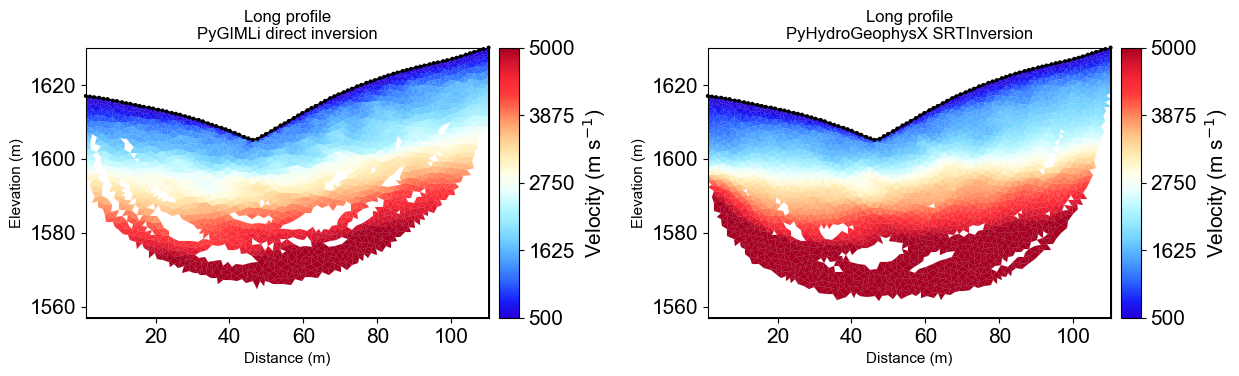

In [ ]:
plot_direct_vs_custom(
    mesh=mesh_inv,
    direct_model=velocity_data_long_direct,
    custom_model=velocity_data_long_custom,
    direct_coverage=coverage_long_direct,
    custom_coverage=coverage_long_custom,
    sensors=datasrt.sensors(),
    output_name="seismic_velocity_long_comparison.tiff",
    velocity_limits=(500.0, 5000.0),
    title_prefix="Long profile",
)
###############################################################################
# Long Profile Direct vs Custom Inversion
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#
# The same mesh, regularization, and velocity bounds are used for both inversion
# paths: PyGIMLi direct inversion and package-level `SRTInversion`.
# Both panels are shown with standardized coverage masking.


### Get subsurface structure for hydrologic modeling



In [ ]:
# Assuming TT.model.array() gives you the velocity values
velocity_data = velocity_data_long_direct

# Call the function with velocity data
# Get subsurface structure (Regolith) for hydrologic modeling
smooth_x1, smooth_z1 = extract_velocity_interface(mesh_inv, velocity_data, threshold=1200,interval = 5)

# Get subsurface structure (Fractured bedrock) for hydrologic modeling
# Here we limit the x range to extract the structure area within the coverage as shown in the figure
smooth_x2, smooth_z2 = extract_velocity_interface(mesh_inv, velocity_data, threshold=5000,interval = 5, x_min=22, x_max=84)




## plot the extracted interfaces withe filled velocity images


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


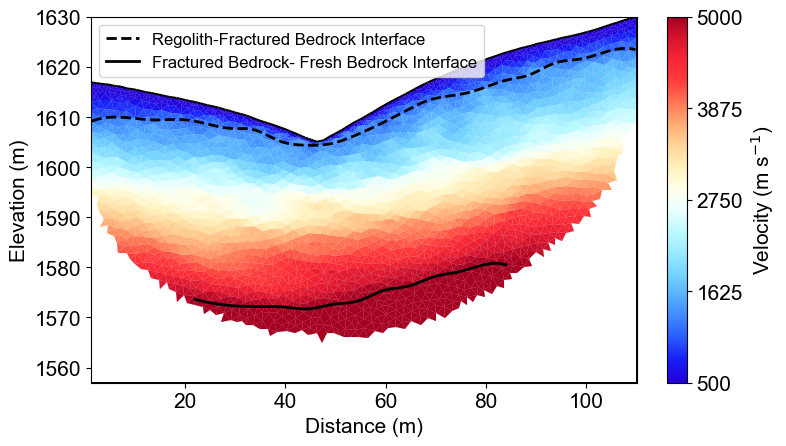

In [ ]:
## plot the extracted interfaces withe filled velocity images
filled_cov1 = fill_holes_2d(pos, TT.standardizedCoverage())

fig = plt.figure(figsize=[8,9])
ax1 = fig.add_subplot(1,1,1)
pg.show(mesh_inv, velocity_data_long_direct,cMap=fixed_cmap,coverage = filled_cov1,ax = ax1,label='Velocity (m s$^{-1}$)',
        xlabel="Distance (m)", ylabel="Elevation (m)",pad=0.3,cMin =500, cMax=5000
       ,orientation="vertical")
ax1.set_xlabel("Distance (m)", fontsize=15)
ax1.set_ylabel("Elevation (m)", fontsize=15)
ax1.plot(smooth_x1, smooth_z1, 'k--', linewidth=2, label='Regolith-Fractured Bedrock Interface')
ax1.plot(smooth_x2, smooth_z2, 'k-', linewidth=2, label='Fractured Bedrock- Fresh Bedrock Interface')
ax1.legend(fontsize=12)
np.savetxt(os.path.join(output_dir, 'regolith_interface.txt'), np.c_[smooth_x1, smooth_z1])
np.savetxt(os.path.join(output_dir, 'fractured_bedrock_interface.txt'), np.c_[smooth_x2, smooth_z2])
###############################################################################
# Automated Interface Extraction
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#
# Two critical geological boundaries extracted from velocity thresholds: 
# regolith-bedrock interface (dashed line, 1200 m/s) and fractured-fresh 
# bedrock interface (solid line, 5000 m/s). Interfaces are smoothed and 
# exported as text files for integration with hydrogeological models.
#
# .. image:: /auto_examples/images/Ex_SRT_inv_fig_02.png
#    :align: center
#    :width: 700px


## Short seismic profiles



In [ ]:
short_data_file = "./results/workflow_example/synthetic_seismic_data.dat"
ttData = tt.load(short_data_file)
TT_short = pg.physics.traveltime.TravelTimeManager()
mesh_inv1 = TT_short.createMesh(ttData , paraMaxCellSize=2, quality=32, paraDepth = 30.0)
TT_short.invert(ttData , mesh = mesh_inv1,lam=50,
          zWeight=0.2,vTop=500, vBottom=5500,
          verbose=1, limits=[300., 8000.])
velocity_data_short_direct = TT_short.model.array()
coverage_short_direct = TT_short.standardizedCoverage()

short_custom_result = run_custom_srt_inversion(
    data_file=short_data_file,
    mesh=mesh_inv1,
    inversion_params=SHORT_SRT_PARAMS,
)
velocity_data_short_custom = compare_models(
    velocity_data_short_direct,
    short_custom_result,
)
coverage_short_custom = short_custom_result.coverage



28/03/26 - 21:05:44 - pyGIMLi - INFO - Found 1 regions.


28/03/26 - 21:05:44 - pyGIMLi - INFO - Found 1 regions.


28/03/26 - 21:05:44 - pyGIMLi - INFO - Creating forward mesh from region infos.


28/03/26 - 21:05:44 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


28/03/26 - 21:05:44 - pyGIMLi - INFO - Create gradient starting model. 500: 5500


...

accepted_step: 1.000000
update_norm: 3.674074e+00
-------------------Iteration: 3 ---------------------------


chi2 (pre-update): 1.004652
dPhi (pre-update): 0.312568
phi_d (pre-update): 1069.954715
phi_m (pre-update): 17.036322
obj (pre-update): 1921.770809
lambda: 50.000000


accepted_step: 1.000000
update_norm: 1.909639e+00
-------------------Iteration: 4 ---------------------------


chi2 (pre-update): 0.983845
dPhi (pre-update): 0.020711
phi_d (pre-update): 1047.794587
phi_m (pre-update): 16.622764
obj (pre-update): 1878.932781
lambda: 50.000000
Converged: stopping criterion reached.


End of inversion


In [ ]:
x1, y1, triangles1, _, dataIndex1 = createTriangles(mesh_inv1)
z1 = pg.meshtools.cellDataToNodeData(mesh_inv1, velocity_data_short_direct)
pos = np.array(mesh_inv1.cellCenters())
filled_cov1 = fill_holes_2d(pos, TT_short.standardizedCoverage())



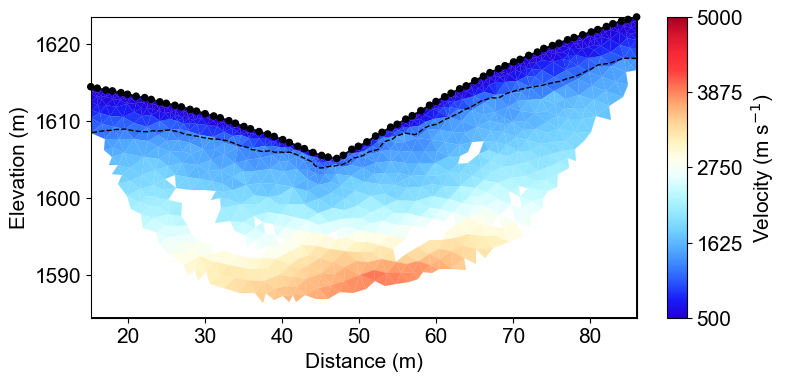

In [ ]:
params = {'legend.fontsize': 15,
          #'figure.figsize': (15, 5),
         'axes.labelsize': 15,
         'axes.titlesize':16,
         'xtick.labelsize':15,
         'ytick.labelsize':15}
import matplotlib.pylab as pylab
pylab.rcParams.update(params)

plt.rcParams["font.family"] = "Arial"

from palettable.lightbartlein.diverging import BlueDarkRed18_18
fixed_cmap = BlueDarkRed18_18.mpl_colormap

fig = plt.figure(figsize=[8,9])
ax1 = fig.add_subplot(1,1,1)
pg.show(mesh_inv1, velocity_data_short_direct,cMap=fixed_cmap,coverage = TT_short.standardizedCoverage(),ax = ax1,label='Velocity (m s$^{-1}$)',
        xlabel="Distance (m)", ylabel="Elevation (m)",pad=0.3,cMin =500, cMax=5000
       ,orientation="vertical")
ax1.set_xlabel("Distance (m)", fontsize=15)
ax1.set_ylabel("Elevation (m)", fontsize=15)

ax1.tricontour(x1, y1, triangles1, z1, levels=[1200], linewidths=1.0, colors='k', linestyles='dashed')



pg.viewer.mpl.drawSensors(ax1, ttData.sensors(), diam=0.8,
                         facecolor='black', edgecolor='black')
fig.savefig(os.path.join(output_dir, 'seismic_velocity_short.tiff'), dpi=300, bbox_inches='tight')
###############################################################################
# Short Profile Multi-Scale Comparison
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#
# Short profile provides enhanced shallow resolution (0-30m depth) with 
# detailed regolith characterization. Higher ray density improves near-surface 
# velocity mapping while sacrificing deeper penetration. The 1200 m/s interface 
# shows excellent agreement with the long profile.
#
# .. image:: /auto_examples/images/Ex_SRT_inv_fig_03.png
#    :align: center
#    :width: 700px



### Short profile: direct vs custom inversion comparison



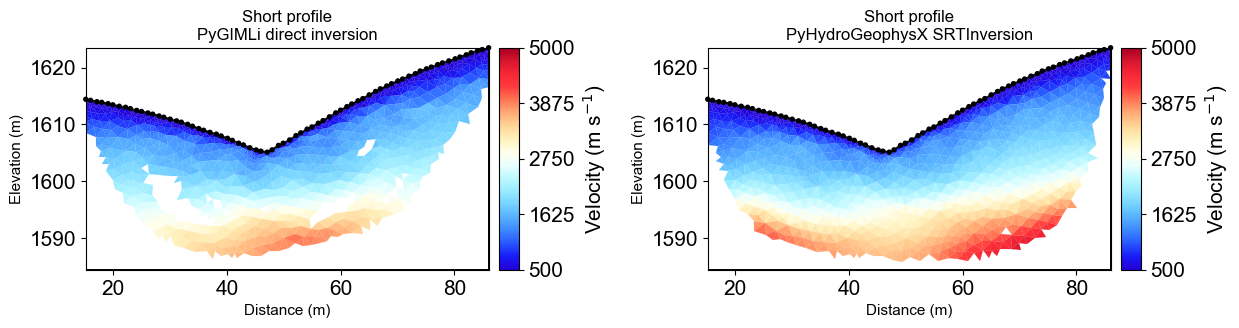

In [ ]:
plot_direct_vs_custom(
    mesh=mesh_inv1,
    direct_model=velocity_data_short_direct,
    custom_model=velocity_data_short_custom,
    direct_coverage=coverage_short_direct,
    custom_coverage=coverage_short_custom,
    sensors=ttData.sensors(),
    output_name="seismic_velocity_short_comparison.tiff",
    velocity_limits=(500.0, 5000.0),
    title_prefix="Short profile",
)
###############################################################################
# Short Profile Direct vs Custom Inversion
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#
# The short-profile comparison uses the same inversion controls for both methods
# and shows that the new packaged inversion reproduces the original direct result
# while preserving shallow structural detail.

###############################################################################
# Summary
# ~~~~~~~
#
# This example demonstrated seismic refraction tomography with automated 
# interface extraction for watershed applications. Key results include 
# three-layer velocity structure resolution, interface extraction at 1200 
# and 5000 m/s thresholds, and direct-vs-custom inversion consistency checks.
#
# The extracted interfaces provide structural constraints for ERT inversions 
# and direct input for hydrogeological models like MODFLOW and ParFlow.
